# 03. Exploratory Data Analysis

변수별 분포와 변수 간 관계를 탐색합니다.

In [19]:
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupShuffleSplit

# 한글 폰트 설정 (Windows 기준)
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

# clean 처리된 데이터 불러오기
df = pd.read_csv('../merged_data_clean.csv')

# 컬럼 그룹 정의 (X값 후보만) — clean 컬럼명 기준
core_cols = ['페니실린농도_P', '기질농도_S', '용존산소_DO2', '발효조부피_V', 'pH', '발효온도_T']

operating_cols = ['교반속도_RPM', '당공급유량_Fs', '공기주입유량_Fg', '산투입유량_Fa',
                  '염기투입유량_Fb', '냉난방수유량_Fc', '가열수유량_Fh', '희석수유량_Fw',
                  'PAA투입유량_Fpaa', '오일투입유량_Foil', '발효조상부압력',
                  '발생열량_Q', '발효조중량_Wt', '배양액제거유량_Fremoved',
                  '암모니아투입량_NH3', '배가스CO2_CO2out', '배가스O2_O2out',
                  '산소소비율_OUR', '이산화탄소발생률_CER']

offline_cols = ['바이오매스농도_오프라인', '페니실린농도_오프라인', 'PAA농도_오프라인',
                '암모니아농도_오프라인', '점도_오프라인']

y_cols = ['총회수량', '종료수확량', '중간수확량']

# 컬럼명 변수 재지정 (기존 코드가 그대로 돌아가도록)
batch_col = '배치번호'
strategy_col = '제어전략그룹'
time_col = '발효시간'

total_col = '총회수량'
during_col = '중간수확량'
end_col = '종료수확량'

p_col = '페니실린농도_P'
s_col = '기질농도_S'
volume_col = '발효조부피_V'

# 시간순 정렬
df = df.sort_values([batch_col, time_col]).copy()

# 배치별 제어전략 그룹 컬럼 대치
df['Strategy'] = df['제어전략그룹']

# 1. Train/Test 배치 단위 분할 확인

In [20]:
# 같은 배치의 시계열이 Train과 Test에 섞이지 않도록
# Batch_ID를 그룹으로 지정해 분할
gss = GroupShuffleSplit(
    n_splits=1,       # 한 번 분할
    test_size=0.2,    # 전체 배치 중 20%를 Test로 사용
    random_state=42   # 팀 전체가 같은 분할을 재현하도록 고정
)

# groups에 Batch_ID를 넣어 배치 단위로 분할
train_idx, test_idx = next(
    gss.split(df, groups=df[batch_col])
)

# 분할된 행으로 Train/Test 데이터 생성
train_df = df.iloc[train_idx].copy()
test_df = df.iloc[test_idx].copy()

# Train/Test에 들어간 고유 배치번호 확인
train_batches = sorted(train_df[batch_col].unique())
test_batches = sorted(test_df[batch_col].unique())

print('Train 배치 수:', len(train_batches))
print('Test 배치 수:', len(test_batches))

print('\nTrain 전략별 배치 수')
print(
    train_df.groupby('Strategy')[batch_col]
    .nunique()
    .reindex(['RC', 'OC', 'APC', 'Fault'])
)

print('\nTest 전략별 배치 수')
print(
    test_df.groupby('Strategy')[batch_col]
    .nunique()
    .reindex(['RC', 'OC', 'APC', 'Fault'])
)

# 같은 배치가 양쪽에 동시에 들어갔는지 확인
overlap = set(train_batches) & set(test_batches)

print('\nTrain/Test 중복 배치:', sorted(overlap))

if len(overlap) == 0:
    print('Train과 Test에 중복된 배치가 없습니다.')
else:
    print('Train과 Test에 같은 배치가 포함되어 있습니다.')

Train 배치 수: 80
Test 배치 수: 20

Train 전략별 배치 수
Strategy
RC       24
OC       23
APC      24
Fault     9
Name: 배치번호, dtype: int64

Test 전략별 배치 수
Strategy
RC       6
OC       7
APC      6
Fault    1
Name: 배치번호, dtype: int64

Train/Test 중복 배치: []
Train과 Test에 중복된 배치가 없습니다.


### 1. 결과 해석

- 전체 100개 배치가 Train 80개, Test 20개로 정상 분리됐다.
- Train과 Test에 중복 배치가 없으므로 같은 배치의 유사한 시계열 값이 양쪽에 섞이는 데이터 누수를 방지했다.
- 이후 골든배치 후보와 상·하위 20% 기준은 Train 80개 배치만 사용해 선정해야 한다.
- Test의 Fault 배치는 1개뿐이므로, 향후 Test 결과만으로 Fault 그룹의 성능을 일반화하지 않는다.
- random_state=42를 사용했기 때문에 팀원들도 같은 Train/Test 구성을 재현할 수 있다.

배치 단위 Train/Test 분할 결과, 양쪽에 중복된 배치가 없는 것을 확인했다. 따라서 골든배치 선정과 모델 개발에는 Train 배치만 사용하고, Test 배치는 최종 평가 단계까지 제외한다.

# 2. Train 데이터를 배치당 한 행으로 정리

In [21]:
total_nunique = (
    train_df.groupby(batch_col)[total_col]
    .nunique()
)

print('배치 내 총회수량 고유값 개수의 최댓값:',
      total_nunique.max())

if total_nunique.max() == 1:
    print('총회수량은 모든 배치 안에서 고정값입니다.')
else:
    print('한 배치 안에서 총회수량이 변하는 경우가 있습니다.')


# 배치마다 총회수량이 고정되어 있으므로 first()로 대표값 추출
# 결과적으로 Train 배치 80개가 각각 한 행으로 정리됨
batch_summary = (
    train_df
    .groupby([batch_col, 'Strategy'], as_index=False)
    .agg(
        총회수량=(total_col, 'first')
    )
)

print('\n배치 요약 데이터 크기:', batch_summary.shape)

print('\n전략별 배치 수')
print(
    batch_summary['Strategy']
    .value_counts()
    .reindex(['RC', 'OC', 'APC', 'Fault'])
)

print('\n배치 요약 데이터 앞부분')
display(batch_summary.head(10))

배치 내 총회수량 고유값 개수의 최댓값: 1
총회수량은 모든 배치 안에서 고정값입니다.

배치 요약 데이터 크기: (80, 3)

전략별 배치 수
Strategy
RC       24
OC       23
APC      24
Fault     9
Name: count, dtype: int64

배치 요약 데이터 앞부분


,배치번호,Strategy,총회수량
0,2,RC,2326000.0
1,3,RC,2675300.0
2,4,RC,1886700.0
3,6,RC,2388700.0
4,7,RC,3454600.0
5,8,RC,3877400.0
6,9,RC,4083100.0
7,10,RC,1982000.0
8,12,RC,3970100.0
9,14,RC,3585600.0


### 2. 결과 해석
 총회수량의 배치 내 고유값이 모두 1개이므로, 총회수량은 시간에 따라 변하는 센서값이 아니라 배치별로 하나씩 부여된 성과지표임을 확인했다.
 
- Train 데이터가 배치당 한 행으로 정리되어 (80, 3) 형태가 됐다.
- 전략별 배치 수도 Step 1과 동일하므로 요약 과정에서 빠지거나 중복된 배치가 없다.
- 이제 시계열 행 개수의 영향을 받지 않고, 배치별 총회수량을 동일한 단위로 비교할 수 있다.
- 1·5·11번처럼 표에 보이지 않는 번호가 있는 것은 해당 배치가 Test에 포함됐기 때문이며 정상이다.

총회수량은 배치 내 고정값임을 확인했다. 따라서 Train 데이터에서 배치당 한 행의 요약 데이터를 생성했으며, 이후 골든배치 후보 선정은 이 배치 단위 데이터를 기준으로 진행한다.

# 3. 전략별 상하위 20% 선정 개수 계산

In [22]:
# 현재는 정상 운전전략인 RC·OC·APC만 계산
# Fault 포함 여부는 아직 최종 결정 전이므로 제외
target_strategies = ['RC', 'OC', 'APC']

selection_count = []

for strategy in target_strategies:

    # 해당 전략의 Train 배치 수
    n_batches = len(
        batch_summary[
            batch_summary['Strategy'] == strategy
        ]
    )

    # 배치 수의 정확한 20%
    raw_20pct = n_batches * 0.20

    # 소수점 버림 시 선정 개수
    floor_count = int(raw_20pct)

    # 소수점 올림 시 선정 개수
    ceil_count = math.ceil(raw_20pct)

    selection_count.append({
        'Strategy': strategy,
        'Train_배치수': n_batches,
        '배치수×20%': raw_20pct,
        '버림_선정수': floor_count,
        '올림_선정수': ceil_count,
        '실제_선정비율(%)': ceil_count / n_batches * 100
    })

# 결과를 표로 변환
selection_count_df = pd.DataFrame(selection_count)

display(selection_count_df.round(2))

,Strategy,Train_배치수,배치수×20%,버림_선정수,올림_선정수,실제_선정비율(%)
0,RC,24,4.8,4,5,20.83
1,OC,23,4.6,4,5,21.74
2,APC,24,4.8,4,5,20.83


### 3. 결과 해석

- RC와 APC는 Train 배치가 각각 24개이므로 20%는 4.8개다.
- OC는 Train 배치가 23개이므로 20%는 4.6개다.
- 배치 일부만 선택할 수 없으므로 정수 처리가 필요하다.
- 버림을 적용하면 각 전략에서 4개만 선정되어 실제 비율이 약 16.7~17.4%로 20%보다 작아진다.
- 올림을 적용하면 각 전략에서 5개가 선정되어 실제 비율은 약 20.8~21.7%가 된다.

상·하위 20%가 과소 선정되는 것을 방지하기 위해 소수점 올림을 적용한다. 이에 따라 RC·OC·APC에서 각각 5개 배치를 선정한다. 이 기준은 후보 결과를 확인하기 전에 동일하게 적용한다.

Fault는 골든배치 포함 여부가 결정되지 않았으므로 현재 계산에서 제외한다.

# 4. 실제 상하위 20% 배치 선정

In [23]:
ranking_tables = []

for strategy in target_strategies:

    # 해당 전략의 배치만 가져온 후
    # 총회수량이 높은 순서로 정렬
    strategy_df = (
        batch_summary[
            batch_summary['Strategy'] == strategy
        ]
        .sort_values(
            by=['총회수량', batch_col],
            ascending=[False, True]
        )
        .reset_index(drop=True)
    )

    # Step 3에서 계산한 전략별 선정 개수 가져오기
    n_select = int(
        selection_count_df.loc[
            selection_count_df['Strategy'] == strategy,
            '올림_선정수'
        ].iloc[0]
    )

    # 총회수량 순위 생성
    # 1위가 총회수량이 가장 높은 배치
    strategy_df['총회수량_순위'] = np.arange(
        1, len(strategy_df) + 1
    )

    # 우선 모든 배치를 중간 그룹으로 설정
    strategy_df['선정구분'] = '중간'

    # 앞에서부터 5개는 상위 20%
    strategy_df.loc[
        strategy_df.index[:n_select],
        '선정구분'
    ] = '상위 20%'

    # 뒤에서부터 5개는 하위 20%
    strategy_df.loc[
        strategy_df.index[-n_select:],
        '선정구분'
    ] = '하위 20%'

    ranking_tables.append(strategy_df)

# 세 전략의 결과를 하나의 데이터프레임으로 합치기
ranking_df = pd.concat(
    ranking_tables,
    ignore_index=True
)

# 상위 20% 결과
top_20_df = (
    ranking_df[
        ranking_df['선정구분'] == '상위 20%'
    ]
    .sort_values(
        ['Strategy', '총회수량'],
        ascending=[True, False]
    )
)

# 하위 20% 결과
bottom_20_df = (
    ranking_df[
        ranking_df['선정구분'] == '하위 20%'
    ]
    .sort_values(
        ['Strategy', '총회수량'],
        ascending=[True, True]
    )
)

print('1. 전략별 총회수량 상위 20%')
display(
    top_20_df[[
        'Strategy',
        batch_col,
        '총회수량',
        '총회수량_순위'
    ]]
)

print('2. 전략별 총회수량 하위 20%')
display(
    bottom_20_df[[
        'Strategy',
        batch_col,
        '총회수량',
        '총회수량_순위'
    ]]
)

1. 전략별 총회수량 상위 20%


,Strategy,배치번호,총회수량,총회수량_순위
47,APC,85,4044300.0,1
48,APC,63,3991800.0,2
49,APC,66,3842700.0,3
50,APC,83,3837100.0,4
51,APC,79,3825600.0,5
24,OC,57,4059100.0,1
25,OC,60,3802300.0,2
26,OC,55,3784400.0,3
27,OC,52,3757800.0,4
28,OC,35,3537900.0,5


2. 전략별 총회수량 하위 20%


,Strategy,배치번호,총회수량,총회수량_순위
70,APC,88,3059300.0,24
69,APC,61,3062600.0,23
68,APC,75,3099500.0,22
67,APC,72,3277100.0,21
66,APC,89,3291400.0,20
46,OC,44,1474100.0,23
45,OC,36,1754100.0,22
44,OC,43,2212400.0,21
43,OC,42,2358500.0,20
42,OC,38,2391500.0,19


### 4. 결과 해석

- RC·OC·APC에서 각각 5개씩, 총 15개가 상위 20% 후보로 선정됐다.
- 이 배치들은 총회수량만을 기준으로 뽑은 1차 골든배치 후보이며, 최종 골든배치로 확정된 것은 아니다.

전략별 상위 20%
- RC: 9, 12, 26, 8, 17
- OC: 57, 60, 55, 52, 35
- APC: 85, 63, 66, 83, 79

전략별 하위 20%
- RC: 29, 4, 24, 10, 18
- OC: 44, 36, 43, 42, 38
- APC: 88, 61, 75, 72, 89

중요한 해석

APC 하위 20%의 총회수량은 약 306만~329만으로, RC·OC의 일부 상위 배치와 비슷하거나 더 높다. 따라서 전체 배치를 한꺼번에 비교하면 APC 배치가 대부분 우수하게 평가될 수 있다.

전략마다 성과 수준과 운전 패턴이 다르므로, 전체 배치를 섞지 않고 RC·OC·APC 내부에서 각각 상·하위 20%를 선정하는 것이 적절하다.

단, 하위 20%는 실제 이상 배치라는 뜻이 아니라 해당 전략 안에서 총회수량 순위가 낮은 배치라는 의미다.

# 5. 전략별 총회수량 전체 순위 시각화

회색은 중간 배치, 빨간색은 상위 20%, 파란색은 하위 20%입니다.

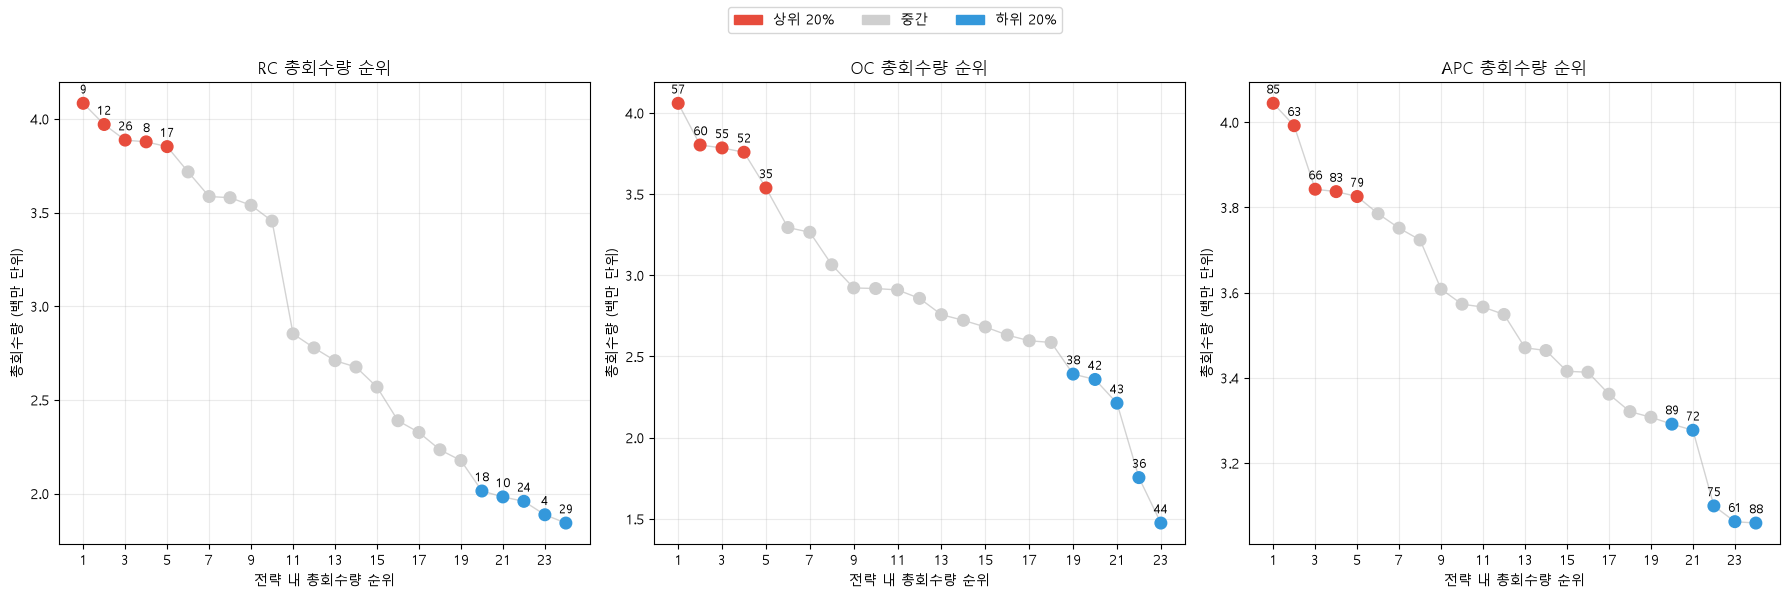

In [24]:
from matplotlib.patches import Patch

# 선정 구분별 색상
color_map = {
    '상위 20%': '#E74C3C',  # 빨간색
    '중간': '#CFCFCF',      # 회색
    '하위 20%': '#3498DB'   # 파란색
}

# RC·OC·APC 그래프를 각각 생성
fig, axes = plt.subplots(
    1, 3,
    figsize=(18, 6)
)

for ax, strategy in zip(axes, target_strategies):

    # 해당 전략을 총회수량 순위대로 정렬
    plot_df = (
        ranking_df[
            ranking_df['Strategy'] == strategy
        ]
        .sort_values('총회수량_순위')
        .copy()
    )

    # 그래프에서 읽기 쉽게 백만 단위로 변환
    plot_df['총회수량_백만'] = (
        plot_df['총회수량'] / 1_000_000
    )

    # 순위에 따른 총회수량 흐름 표시
    ax.plot(
        plot_df['총회수량_순위'],
        plot_df['총회수량_백만'],
        color='lightgray',
        linewidth=1,
        zorder=1
    )

    # 상위·중간·하위 구분에 따라 점 색상 지정
    point_colors = plot_df['선정구분'].map(color_map)

    ax.scatter(
        plot_df['총회수량_순위'],
        plot_df['총회수량_백만'],
        c=point_colors,
        s=70,
        zorder=2
    )

    # 상위·하위 20% 배치에만 Batch_ID 표시
    selected_df = plot_df[
        plot_df['선정구분'] != '중간'
    ]

    for _, row in selected_df.iterrows():
        ax.annotate(
            str(int(row[batch_col])),
            (
                row['총회수량_순위'],
                row['총회수량_백만']
            ),
            xytext=(0, 7),
            textcoords='offset points',
            ha='center',
            fontsize=9
        )

    ax.set_title(f'{strategy} 총회수량 순위')
    ax.set_xlabel('전략 내 총회수량 순위')
    ax.set_ylabel('총회수량 (백만 단위)')
    ax.set_xticks(
        range(1, len(plot_df) + 1, 2)
    )
    ax.grid(alpha=0.25)

# 공통 범례
legend_items = [
    Patch(color='#E74C3C', label='상위 20%'),
    Patch(color='#CFCFCF', label='중간'),
    Patch(color='#3498DB', label='하위 20%')
]

fig.legend(
    handles=legend_items,
    loc='upper center',
    ncol=3
)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

### 5. 결과 해석

- 총회수량 기준 상·하위 20% 배치가 전략별로 명확하게 표시됐다.
- RC는 상위 5개가 약 385만~408만에 모여 있고, 10위 이후부터 총회수량이 크게 떨어진다.
- OC는 57번이 가장 높으며, 60·55·52번이 비슷한 수준이다. 35번 이후부터 감소 폭이 커진다.
- APC는 다른 전략보다 전체 총회수량이 높고 배치 간 차이가 작다. APC 하위 20%도 약 306만~329만으로 RC·OC의 일부 중상위 배치보다 높다.

중요한 해석

전략별 성과 수준이 다르므로 전체 배치를 섞어서 상위 20%를 선정하면 APC에 후보가 집중될 수 있다. 따라서 RC·OC·APC 내부에서 각각 후보를 선정하는 현재 방식이 전략별 운전 특성을 반영하는 데 적절하다.

다만 상위 20%는 후보 수를 일관되게 정하기 위한 규칙이다. 특히 APC는 5위와 6위 차이가 크지 않아 총회수량만으로 자연스럽게 구분되는 경계라고 보기는 어렵다. 최종 골든배치를 정하려면 최종 농도와 농도 궤적도 함께 확인해야 한다.

# 6. 상위 20% 후보의 최종 농도 순위 확인

In [25]:
# 시간순으로 정렬한 Train 데이터에서
# 배치별 최종 농도와 최대 농도 계산
batch_kpi = (
    train_df
    .sort_values([batch_col, time_col])
    .groupby([batch_col, 'Strategy'], as_index=False)
    .agg(
        총회수량=(total_col, 'first'),

        # 각 배치의 마지막 시점 페니실린 농도
        최종농도=(p_col, 'last'),

        # 전체 운전기간 중 가장 높은 페니실린 농도
        최대농도=(p_col, 'max'),

        # 배치의 최종 운전시간
        운전시간=(time_col, 'max')
    )
)

# 전략 내부에서 최종 농도의 백분위 계산
# 값이 1에 가까울수록 해당 전략에서 최종 농도가 높음
batch_kpi['최종농도_백분위'] = (
    batch_kpi
    .groupby('Strategy')['최종농도']
    .rank(pct=True)
)

# 앞에서 계산한 총회수량 순위와 선정구분을 연결
batch_kpi = batch_kpi.merge(
    ranking_df[[
        batch_col,
        'Strategy',
        '총회수량_순위',
        '선정구분'
    ]],
    on=[batch_col, 'Strategy'],
    how='left'
)

# 총회수량 상위 20% 후보만 추출
top_candidates = (
    batch_kpi[
        batch_kpi['선정구분'] == '상위 20%'
    ]
    .copy()
)

# 최종 농도 수준에 따라 후보 유형 구분
top_candidates['후보유형'] = '최종농도 중간 수준'

# 총회수량과 최종 농도가 모두 상위 20%인 경우
top_candidates.loc[
    top_candidates['최종농도_백분위'] >= 0.80,
    '후보유형'
] = '총회수량·최종농도 모두 상위 20%'

# 최종 농도가 전략 내 하위 50%보다 낮은 경우
# 50%와 정확히 같은 배치는 경계값이므로 포함하지 않음
top_candidates.loc[
    top_candidates['최종농도_백분위'] < 0.50,
    '후보유형'
] = '총회수량 상위·최종농도 하위 50%'

# 전략과 총회수량 순위대로 정렬
top_candidates = top_candidates.sort_values(
    ['Strategy', '총회수량_순위']
)

display(
    top_candidates[[
        'Strategy',
        batch_col,
        '총회수량',
        '총회수량_순위',
        '최종농도',
        '최대농도',
        '최종농도_백분위',
        '후보유형'
    ]].round(3)
)

# 후보 유형별 배치번호 요약
print('\n후보 유형별 Batch_ID')

for candidate_type, group in top_candidates.groupby('후보유형'):
    print(
        candidate_type,
        ':',
        sorted(group[batch_col].tolist())
    )

,Strategy,배치번호,총회수량,총회수량_순위,최종농도,최대농도,최종농도_백분위,후보유형
65,APC,85,4044300.0,1.0,31.898,31.898,0.917,총회수량·최종농도 모두 상위 20%
49,APC,63,3991800.0,2.0,28.677,28.739,0.458,총회수량 상위·최종농도 하위 50%
52,APC,66,3842700.0,3.0,26.655,26.691,0.167,총회수량 상위·최종농도 하위 50%
64,APC,83,3837100.0,4.0,27.214,27.214,0.250,총회수량 상위·최종농도 하위 50%
61,APC,79,3825600.0,5.0,31.531,31.546,0.875,총회수량·최종농도 모두 상위 20%
43,OC,57,4059100.0,1.0,32.518,32.518,0.957,총회수량·최종농도 모두 상위 20%
46,OC,60,3802300.0,2.0,18.818,25.136,0.435,총회수량 상위·최종농도 하위 50%
41,OC,55,3784400.0,3.0,27.268,28.272,0.783,최종농도 중간 수준
39,OC,52,3757800.0,4.0,22.300,26.519,0.522,최종농도 중간 수준
25,OC,35,3537900.0,5.0,28.302,28.302,0.870,총회수량·최종농도 모두 상위 20%



후보 유형별 Batch_ID
총회수량 상위·최종농도 하위 50% : [9, 60, 63, 66, 83]
총회수량·최종농도 모두 상위 20% : [8, 35, 57, 79, 85]
최종농도 중간 수준 : [12, 17, 26, 52, 55]


### 6. 결과 해석

총회수량 상위 20% 후보 15개가 최종 농도에 따라 정확히 세 그룹으로 나뉘었다.

1. 두 지표가 모두 높은 후보
- RC: 8
- OC: 35, 57
- APC: 79, 85

총회수량과 최종 농도가 모두 전략 내 상위 20%이므로 현재 가장 강한 골든배치 후보다.

2. 총회수량은 높지만 최종 농도가 낮은 후보
- RC: 9
- OC: 60
- APC: 63, 66, 83

다만 이 다섯 배치를 같은 유형의 이상으로 해석하면 안 된다.

- 9·60번은 최대농도보다 최종농도가 크게 낮아 후반부 농도 하락이 의심된다.
- 63·66·83번은 최대농도와 최종농도가 거의 같아 후반부 하락은 없다. 다만 APC 안에서 농도 수준이 상대적으로 낮다.

즉, 9·60번은 후반부 성능 저하형, 63·66·83번은 상대적 저농도형에 가까울 가능성이 있다.

3. 최종 농도가 중간 수준인 후보
- RC: 12, 17, 26
- OC: 52, 55

12·26번은 최종 농도 백분위가 각각 0.792와 0.750으로 상위 20% 기준에 근접한다. 단순히 0.8 미만이라는 이유로 제외하면 안 된다.

또한 52번은 최대농도 26.519에서 최종농도 22.300으로 감소해 추가 확인이 필요하다.

최종 농도 백분위는 각 전략 안에서의 상대적인 순위다. 따라서 최종 농도 하위 50%라는 표현이 곧 절대적으로 낮은 농도나 공정 이상을 의미하지는 않는다.

## 확인된 내용 정리
1. Train/Test 분할 검증 완료: GroupShuffleSplit으로 배치 단위 80/20 분할, 중복 없음 확인 (Train: RC24/OC23/APC24/Fault9)
2. 전략별 상위 20% 후보가 3개 그룹으로 자연스럽게 나뉨 (총회수량 vs 최종농도 교차분석):
- 총회수량·최종농도 모두 상위: RC 8, OC 35·57, APC 79·85 (5개 → 가장 강한 골든배치 후보)
- 총회수량 상위·최종농도 하위: RC 9, OC 60, APC 63·66·83 (기존 "이상후보"와 동일)
- 최종농도 중간 수준: RC 12·17·26, OC 52·55 (0.8 문턱값 근처라 성급히 제외하면 안 된다고 명시)
3. "이상후보" 내부에서도 유형이 갈린다는 걸 정량적으로 재확인: 9·60번(최대농도 대비 최종농도 급락 = 후반부 저하형) vs 63·66·83번(최대≈최종 = 상대적 저농도형) — 저희가 그래프로 확인했던 것과 정확히 일치

# 1. P(t) 궤적 오버레이 — 이상후보 vs 대조군

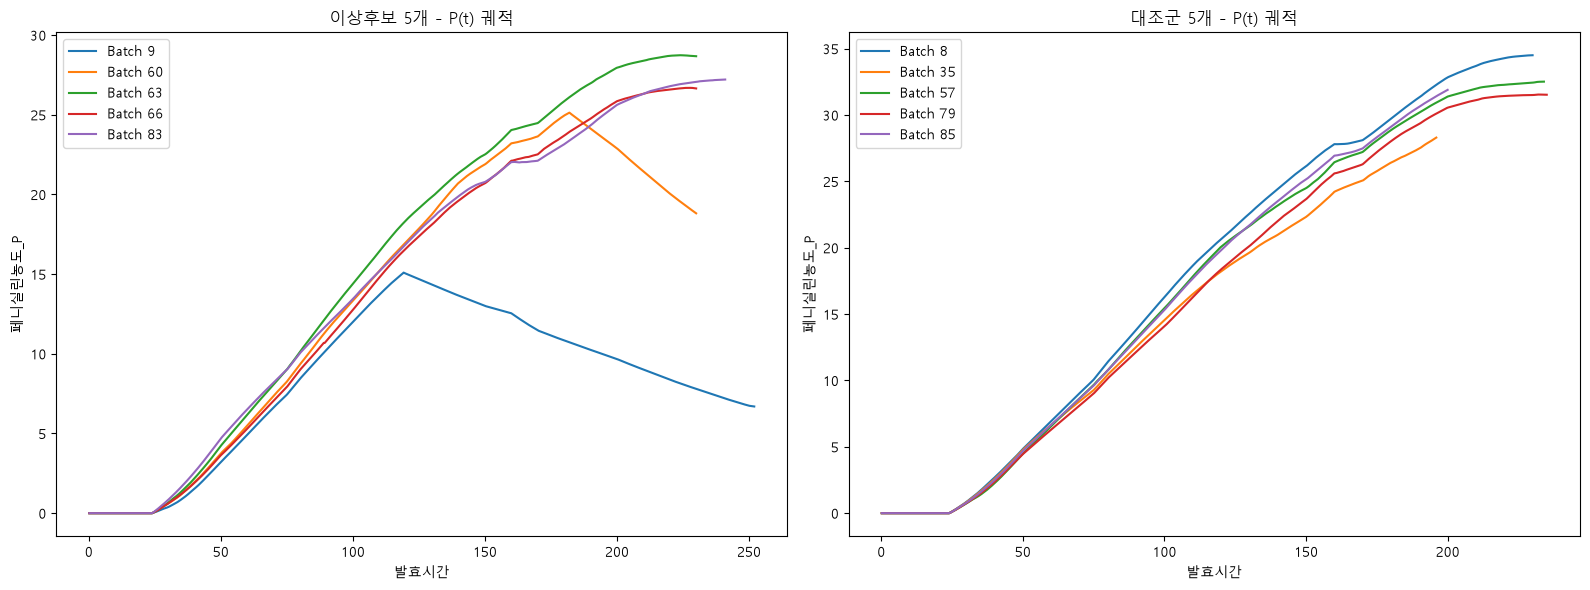

In [26]:
# 확정된 배치 목록
# - 이상후보: 총회수량은 상위20%인데 최종농도는 하위50%인 배치 (지표 불일치)
# - 대조군: 총회수량, 최종농도 둘 다 상위20%인 배치 (지표 일치, 정상 비교기준)
anomaly = [9, 60, 63, 66, 83]
control = [8, 35, 57, 79, 85]

# 그래프 두 개를 나란히 그릴 도화지 준비 (1행 2열)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- 왼쪽 그래프: 이상후보 5개 배치의 시간에 따른 P(농도) 변화 ---
for b in anomaly:
    sub = df[df[batch_col]==b]  # 해당 배치번호 데이터만 추출
    axes[0].plot(sub[time_col], sub[p_col], label=f'Batch {b}')  # 시간(x) vs 농도(y) 선그래프
axes[0].set_title('이상후보 5개 - P(t) 궤적')
axes[0].set_xlabel(time_col); axes[0].set_ylabel(p_col)
axes[0].legend()  # 범례(어떤 색이 몇 번 배치인지) 표시

# --- 오른쪽 그래프: 대조군 5개 배치도 동일한 방식으로 ---
for b in control:
    sub = df[df[batch_col]==b]
    axes[1].plot(sub[time_col], sub[p_col], label=f'Batch {b}')
axes[1].set_title('대조군 5개 - P(t) 궤적')
axes[1].set_xlabel(time_col); axes[1].set_ylabel(p_col)
axes[1].legend()

plt.tight_layout()  # 그래프 간 간격 자동 조정(겹침 방지)
plt.show()

# 2. 9번·60번 후반부 농도 저하 원인 확인 — 정점 시점의 기질농도(S) 비교

"9번·60번 배치는 발효 후반부에 미생물이 기질(당)을 더 이상 소비하지 못하게 되면서, 기질이 소모되지 않고 쌓이고(축적), 그 결과 페니실린 생산도 멈추거나 오히려 줄어드는 것 아닐까?"

In [27]:
# (63·66·83번은 후반부 하락이 없으므로 이번 분석 대상에서 제외)

decline_batches = [9, 60]

for b in decline_batches:
    sub = df[df[batch_col] == b].reset_index(drop=True)

    # 페니실린 농도가 가장 높았던 시점(정점)을 찾음
    peak_idx = sub[p_col].idxmax()
    peak_time = sub.loc[peak_idx, time_col]
    peak_p = sub.loc[peak_idx, p_col]
    final_p = sub[p_col].iloc[-1]

    # 정점 시점의 기질농도, 배치 종료 시점의 기질농도
    s_at_peak = sub.loc[peak_idx, s_col]
    s_at_end = sub[s_col].iloc[-1]

    print(f'=== Batch {b} ===')
    print(f'정점 시점: {peak_time}h, 정점 농도: {peak_p:.2f} g/L, 최종 농도: {final_p:.2f} g/L')
    print(f'정점 시점 기질농도(S): {s_at_peak:.3f} g/L')
    print(f'종료 시점 기질농도(S): {s_at_end:.3f} g/L')
    print(f'기질농도 변화량(종료-정점): {s_at_end - s_at_peak:+.3f} g/L')
    print()

=== Batch 9 ===
정점 시점: 119.2h, 정점 농도: 15.10 g/L, 최종 농도: 6.70 g/L
정점 시점 기질농도(S): 0.006 g/L
종료 시점 기질농도(S): 83.956 g/L
기질농도 변화량(종료-정점): +83.950 g/L

=== Batch 60 ===
정점 시점: 182.0h, 정점 농도: 25.14 g/L, 최종 농도: 18.82 g/L
정점 시점 기질농도(S): 0.020 g/L
종료 시점 기질농도(S): 21.913 g/L
기질농도 변화량(종료-정점): +21.893 g/L



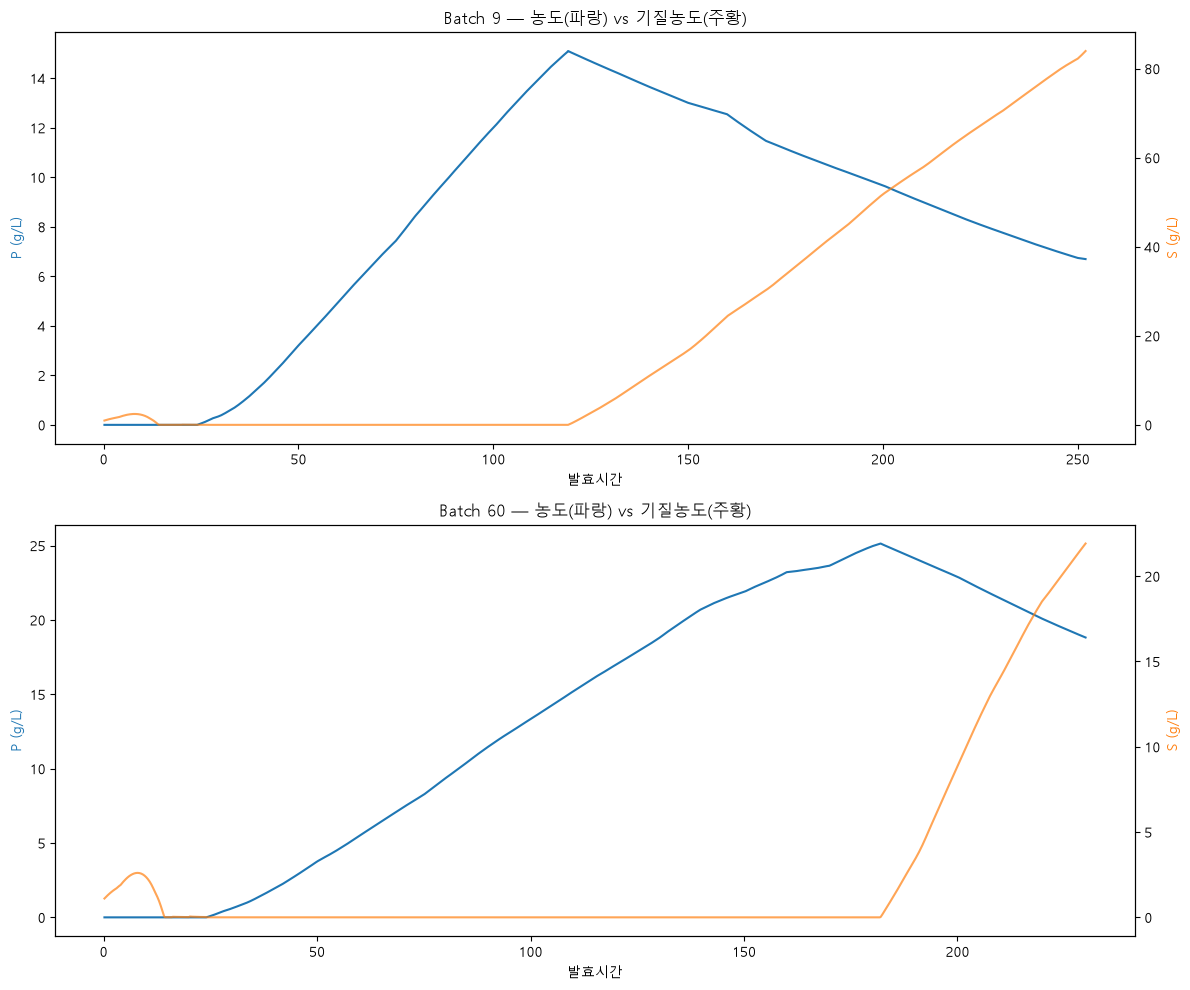

In [28]:
# 정점 이후 구간에서 농도(P)와 기질농도(S)가 함께 어떻게 움직이는지 확인
fig, axes = plt.subplots(len(decline_batches), 1, figsize=(12, 5 * len(decline_batches)))

for i, b in enumerate(decline_batches):
    sub = df[df[batch_col] == b]
    ax = axes[i]

    ax.plot(sub[time_col], sub[p_col], color='tab:blue', label='P (페니실린농도)')
    ax.set_xlabel(time_col)
    ax.set_ylabel('P (g/L)', color='tab:blue')

    ax2 = ax.twinx()
    ax2.plot(sub[time_col], sub[s_col], color='tab:orange', alpha=0.7, label='S (기질농도)')
    ax2.set_ylabel('S (g/L)', color='tab:orange')

    ax.set_title(f'Batch {b} — 농도(파랑) vs 기질농도(주황)')

plt.tight_layout()
plt.show()

### 9번·60번 후반부 농도 저하 원인 — 기질 축적 확인

- **Batch 9**: 정점(119.2h) 시점 기질농도는 0.006 g/L(거의 소진)였는데, 종료 시점엔 83.956 g/L까지 치솟음
- **Batch 60**: 정점(182.0h) 시점 기질농도 0.020 g/L → 종료 시점 21.913 g/L
- 그래프를 보면 **두 배치 모두 P(농도)가 정점을 찍는 바로 그 시점 부근에서 S(기질농도)가 거의 동시에 바닥에서 치솟기 시작**함
- 정점 이전까지는 기질이 거의 0에 가깝게 유지되며(정상적으로 소비되고 있었다는 뜻) 농도가 꾸준히 상승하다가, 정점 이후 기질이 안 먹히고 쌓이면서 농도가 하락하는 패턴이 뚜렷함

**해석 (상관관계 수준으로 표현)**
- 이 두 배치는 **"미생물이 기질을 더 이상 소비하지 못하게 된 시점부터 페니실린 생산이 멈추고 오히려 감소한다"**는 패턴을 보임
- 이건 저희가 이전에 확인했던 Fault 그룹의 특징(기질 축적 + 대사활성 저하)과 **동일한 유형의 현상이 정상 라벨(RC 9번, OC 60번) 배치에서도 나타난 것**으로 보임
- 다만 이게 정확히 "왜" 발생했는지(미생물 자체의 문제인지, 다른 조작변수 이상 때문인지)는 이 분석만으로는 알 수 없어서, "기질 축적과 농도 하락이 같은 시점에 함께 관찰됐다" 정도로 표현하는 게 안전함

# 3. 정점 전후 OUR·DO2 변화 확인

In [29]:
# 9번·60번 정점 전후 OUR(산소소비율), DO2(용존산소) 변화 확인
# Fault 그룹의 특징(기질 증가 + OUR 감소 + DO2 증가 + P 감소)과 같은 패턴인지 검증

our_col = '산소소비율_OUR'
do2_col = '용존산소_DO2'

for b in decline_batches:
    sub = df[df[batch_col] == b].reset_index(drop=True)
    peak_idx = sub[p_col].idxmax()
    peak_time = sub.loc[peak_idx, time_col]

    before = sub[sub[time_col] < peak_time]
    after = sub[sub[time_col] >= peak_time]

    print(f'=== Batch {b} (정점: {peak_time}h) ===')
    print(f'OUR  — 정점 이전: {before[our_col].mean():.3f} → 정점 이후: {after[our_col].mean():.3f} (변화: {after[our_col].mean()-before[our_col].mean():+.3f})')
    print(f'DO2  — 정점 이전: {before[do2_col].mean():.3f} → 정점 이후: {after[do2_col].mean():.3f} (변화: {after[do2_col].mean()-before[do2_col].mean():+.3f})')
    print()

=== Batch 9 (정점: 119.2h) ===
OUR  — 정점 이전: 1.265 → 정점 이후: 0.618 (변화: -0.647)
DO2  — 정점 이전: 13.051 → 정점 이후: 13.382 (변화: +0.331)

=== Batch 60 (정점: 182.0h) ===
OUR  — 정점 이전: 1.397 → 정점 이후: 0.625 (변화: -0.772)
DO2  — 정점 이전: 11.023 → 정점 이후: 11.765 (변화: +0.742)



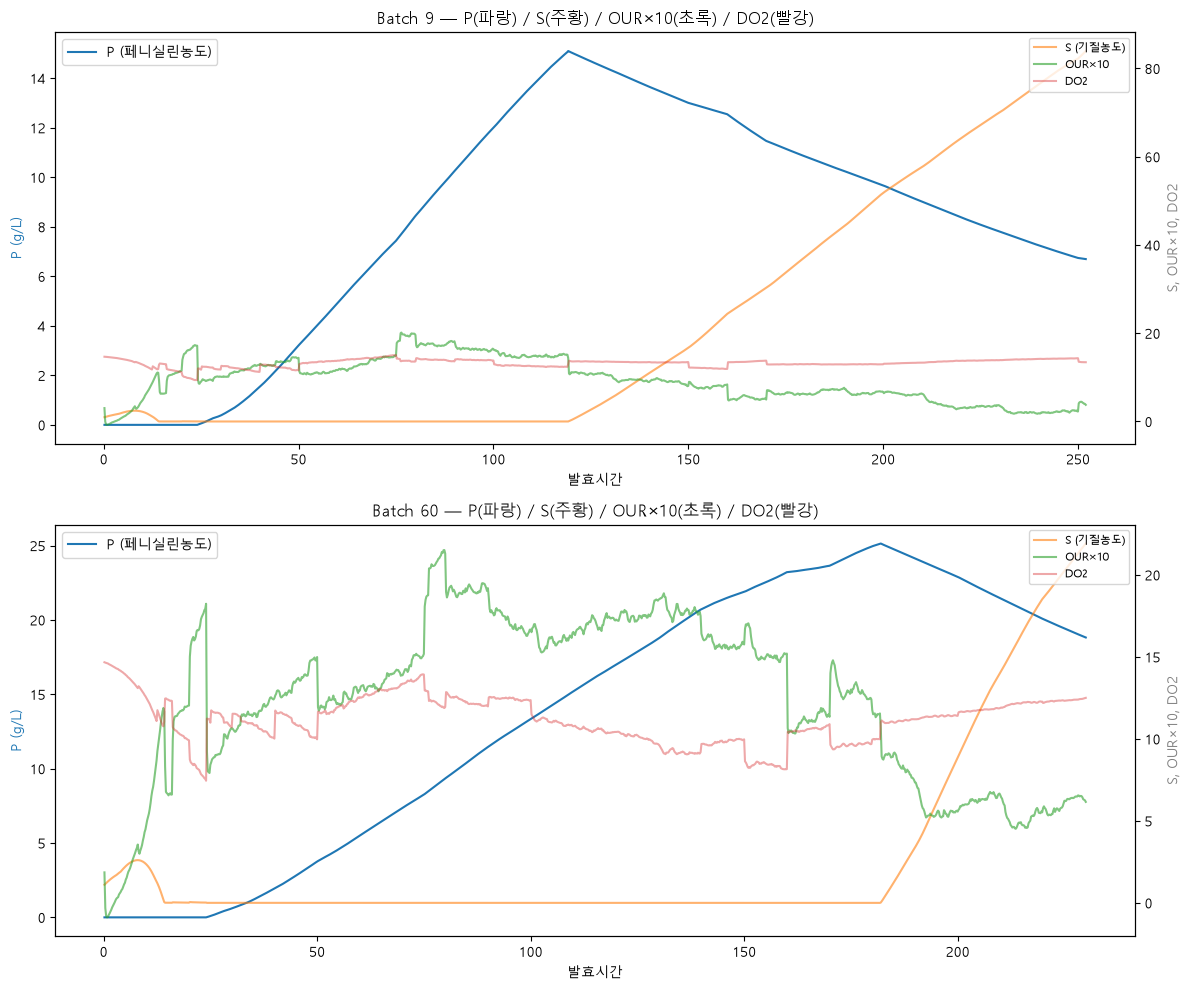

In [30]:
# P, S, OUR, DO2 네 개 한 그래프에서 같이 보기

fig, axes = plt.subplots(len(decline_batches), 1, figsize=(12, 5 * len(decline_batches)))

for i, b in enumerate(decline_batches):
    sub = df[df[batch_col] == b]
    ax = axes[i]

    ax.plot(sub[time_col], sub[p_col], color='tab:blue', label='P (페니실린농도)')
    ax.set_ylabel('P (g/L)', color='tab:blue')
    ax.set_xlabel(time_col)

    ax2 = ax.twinx()
    ax2.plot(sub[time_col], sub[s_col], color='tab:orange', alpha=0.6, label='S (기질농도)')
    ax2.plot(sub[time_col], sub[our_col] * 10, color='tab:green', alpha=0.6, label='OUR×10')
    ax2.plot(sub[time_col], sub[do2_col], color='tab:red', alpha=0.4, label='DO2')
    ax2.set_ylabel('S, OUR×10, DO2', color='gray')

    ax.set_title(f'Batch {b} — P(파랑) / S(주황) / OUR×10(초록) / DO2(빨강)')
    ax.legend(loc='upper left')
    ax2.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

### 9번·60번 — Fault 그룹과 동일한 4가지 패턴 확인 완료

정점(농도 최고점) 전후로 비교한 결과:

| 변수 | Batch 9 | Batch 60 | Fault 그룹 특징 | 일치 여부 |
|---|---|---|---|---|
| 기질농도(S) | 0.006→83.956 (급증) | 0.020→21.913 (급증) | 증가 | ✅ |
| OUR(산소소비율) | 1.265→0.618 (-0.647) | 1.397→0.625 (-0.772) | 감소 | ✅ |
| DO2(용존산소) | 13.051→13.382 (+0.331) | 11.023→11.765 (+0.742) | 증가 | ✅ |
| P(페니실린농도) | 정점 이후 하락 | 정점 이후 하락 | 감소 | ✅ |

**4가지 지표 모두 Fault 그룹의 패턴과 동일한 방향으로 확인됨**

**해석 (여전히 상관관계 수준으로)**
- 정점 시점을 기준으로 산소소비율(OUR)이 뚜렷하게 감소하고(초록선이 정점 부근에서 꺾여 내려감), 동시에 기질농도(S)가 축적되기 시작함
- 이는 "미생물의 대사활동(산소 소비)이 둔화되면서, 기질을 더 이상 소비하지 못하고 쌓이며, 그 결과 산소도 덜 소비되어 DO2가 오르고, 페니실린 생산도 멈추는" 하나의 연결된 흐름으로 해석 가능
- **결론**: RC 9번, OC 60번은 라벨상 정상(Fault=0)이지만, 실제 운전 양상은 Fault 그룹에서 관찰되는 대사활성 저하 패턴과 상관관계 수준에서 일치함
- 다만 이것이 "왜" 일어났는지(장비 이상, 오염, 다른 조작변수 문제 등 근본 원인)는 이 데이터만으로 규명할 수 없으므로, "동일한 패턴이 관찰됐다"까지만 표현하고 원인을 단정하지 않음

# 이것이 왜 중요한 발견인가?
이 결과는 어제 정리한 마스터 문서의 **이진 Fault 라벨만으로 모든 공정 이상 패턴을 설명하기 어렵다**는 주장(Batch 10·30 사례)에 RC 9번·OC 60번이라는 새로운 실증 사례를 하나 더 추가하는 것.

즉:

Fault=1인데 우수한 배치가 있다 (93·97번)
Fault=0인데 Fault와 똑같은 대사이상 패턴을 보이는 배치가 있다 (9번·60번) ← 방금 확인한 것

이 두 방향의 불일치를 모두 손에 쥐게 된 셈이라, "왜 골든배치·이탈점수 같은 연속적 지표가 필요한가"에 대한 근거가 훨씬 탄탄해짐

In [31]:
# Fault 배치 전체를 총회수량 기준으로 순위 확인 (Train 기준)
fault_summary = (
    train_df[train_df[strategy_col] == 'Fault']
    .groupby(batch_col, as_index=False)
    .agg(총회수량=(total_col, 'first'))
    .sort_values('총회수량', ascending=False)
    .reset_index(drop=True)
)
fault_summary['순위'] = fault_summary.index + 1

print(fault_summary)

   배치번호       총회수량  순위
0    93  4447700.0   1
1    97  3894300.0   2
2    96  3595000.0   3
3    94  3584100.0   4
4    95  1954500.0   5
5    92  1752600.0   6
6    98  1730600.0   7
7   100  1555000.0   8
8    99   890830.0   9


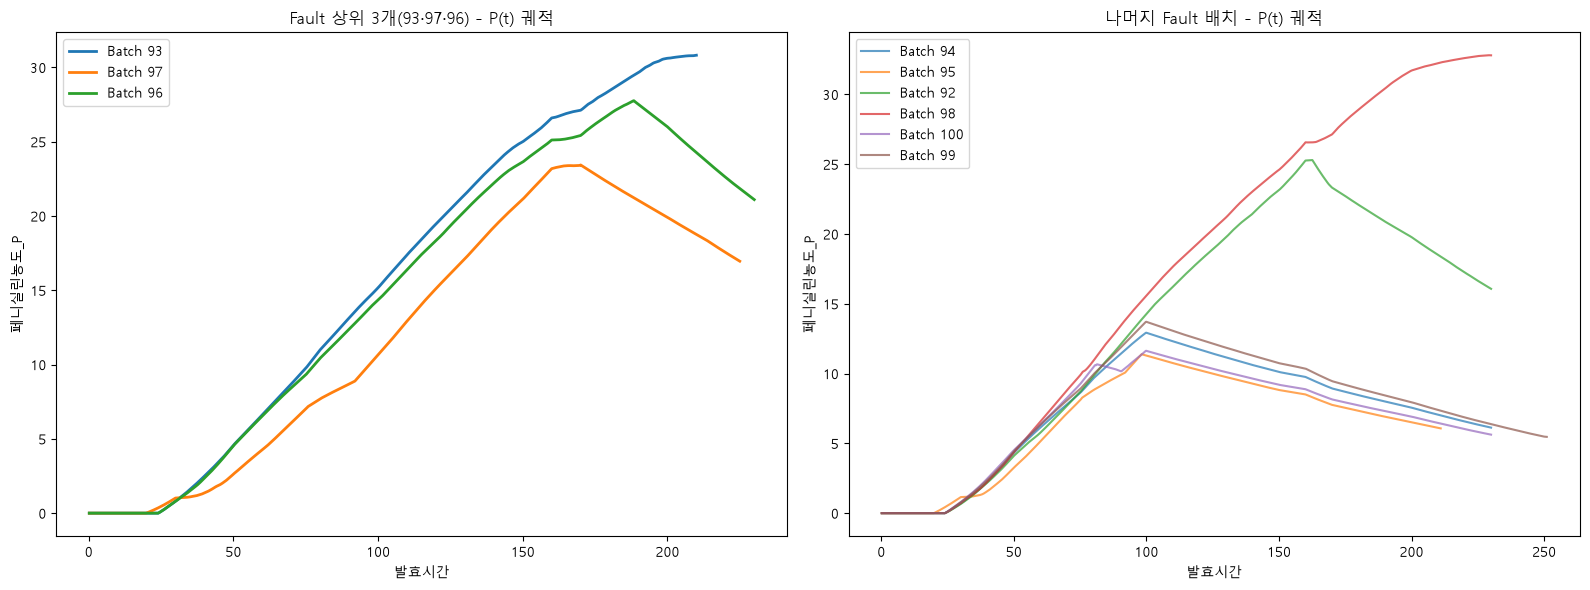

In [32]:
# Fault 배치 상위 3개(고수율) vs 하위 배치들의 P(t) 궤적 비교
fault_top = [93, 97, 96]
fault_others = [b for b in fault_summary[batch_col] if b not in fault_top]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for b in fault_top:
    sub = df[df[batch_col] == b]
    axes[0].plot(sub[time_col], sub[p_col], label=f'Batch {b}', linewidth=2)
axes[0].set_title('Fault 상위 3개(93·97·96) - P(t) 궤적')
axes[0].set_xlabel(time_col); axes[0].set_ylabel(p_col)
axes[0].legend()

for b in fault_others:
    sub = df[df[batch_col] == b]
    axes[1].plot(sub[time_col], sub[p_col], label=f'Batch {b}', alpha=0.7)
axes[1].set_title('나머지 Fault 배치 - P(t) 궤적')
axes[1].set_xlabel(time_col); axes[1].set_ylabel(p_col)
axes[1].legend()

plt.tight_layout()
plt.show()

### Fault 배치 총회수량 순위 및 궤적 확인

**Train 내 순위 (91번은 Test로 빠져서 9개만 있음)**
93(1위, 444.8만) → 97(2위, 389.4만) → 96(3위, 359.5만) → 94(4위, 358.4만, 3위와 거의 차이 없음) → 95(5위) → 92(6위) → 98(7위) → 100(8위) → 99(9위)

**궤적 패턴**
- **93·97·96 (상위 3개)**: 완만하게 상승해서 25~31 g/L 수준에서 정체되거나 소폭 하락. 대체로 안정적인 "정상적 고수율" 모양
- **92 (하위권인데 궤적은 특이)**: 90~100h 근처에서 25까지 올라갔다가 160h 이후 뚜렷하게 꺾여 230h 시점엔 16까지 하락 — **정점 후 급락 패턴(RC 9번·OC 60번과 동일 유형)**
- **98**: 90h부터 230h까지 계속 우상향하며 그래프 끝(약 32)이 최고점 — 하락 없이 꾸준히 상승하는 유형. 총회수량은 낮지만(7위) 농도 궤적만 보면 63·66·83번처럼 안정적으로 우상향하는 축에 가까움
- **94·95·99·100**: 처음부터 쭉 낮은 수준(10~14)에서 큰 변화 없이 유지 — 정점 후 하락이 아니라 "애초에 낮게 시작해서 낮게 끝나는" 다른 유형